# 🧪 Testowanie i Trening Modelu VAR

Notebook do **testowania** oraz **trenowania** modelu VAR (Vector Autoregression),
który jest wykorzystywany w głównym projekcie symulatora prognoz makroekonomicznych.

## Struktura notebooka:
1. Import bibliotek i ładowanie danych
2. Eksploracja danych (EDA)
3. Test stacjonarności (ADF)
4. Dobór optymalnego lagu
5. Trening modelu VAR
6. Analiza wyników i diagnostyka
7. Test prognozy bazowej
8. Test symulacji szoków
9. Zapis wytrenowanego modelu

## 1. Import bibliotek i konfiguracja

In [178]:
import sys, os
import joblib
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja środowiska (Colab / Lokalnie)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Zmień poniższą ścieżkę, jeśli projekt znajduje się w innym folderze na Twoim Google Drive
    PROJECT_ROOT = '/content/drive/MyDrive/Studia_AI_Python/Projekt'
except ImportError:
    # Uruchomienie lokalnie
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import select_coint_rank, VECM
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-darkgrid')

print('Biblioteki zaladowane pomyslnie!')
print(f'Projekt: {PROJECT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Biblioteki zaladowane pomyslnie!
Projekt: /content/drive/MyDrive/Studia_AI_Python/Projekt


## 2. Ładowanie i eksploracja danych (EDA)

In [179]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'processed_data.csv')

if not os.path.exists(DATA_PATH):
    print(f'Brak pliku danych w: {DATA_PATH}')
else:
    df_raw = pd.read_csv(DATA_PATH, index_col='date', parse_dates=True)

    # 1. Transformacja Logarytmiczna (tylko zmienne stricte dodatnie i rosnące)
    # cpi_inflation omijamy, bo to już jest stopa procentowa (i może spadać poniżej zera)
    cols_to_log = ['it_earnings', 'ai_investments', 'it_hiring']
    df_log = df_raw.copy()

    for col in cols_to_log:
        df_log[col] = np.log(df_log[col])

    # 2. Inicjalizacja i dopasowanie skalera (Z-score) na danych zlogarytmizowanych
    scaler = StandardScaler()
    df_scaled_array = scaler.fit_transform(df_log)

    # Tworzymy nasz docelowy DataFrame na w pełni przetworzonych danych
    df = pd.DataFrame(df_scaled_array, index=df_raw.index, columns=df_raw.columns)

    # ZAPIS ARTEFAKTÓW MLOPS DO INFERENCJI PRODUKCYJNEJ
    MODEL_DIR = os.path.join(PROJECT_ROOT, 'data')
    os.makedirs(MODEL_DIR, exist_ok=True)

    scaler_path = os.path.join(MODEL_DIR, 'scaler.joblib')
    joblib.dump(scaler, scaler_path)

    log_meta_path = os.path.join(MODEL_DIR, 'log_transform_meta.joblib')
    joblib.dump(cols_to_log, log_meta_path)

    print(f'✅ Skaler zapisany w: {scaler_path}')
    print(f'✅ Metadane logarytmowania zapisane w: {log_meta_path}')
    print(f'Zaladowano {len(df)} obserwacji, {len(df.columns)} zmiennych')
    print('Dane zlogarytmizowane i ustandaryzowane.')
    display(df.describe().round(2))

✅ Skaler zapisany w: /content/drive/MyDrive/Studia_AI_Python/Projekt/data/scaler.joblib
✅ Metadane logarytmowania zapisane w: /content/drive/MyDrive/Studia_AI_Python/Projekt/data/log_transform_meta.joblib
Zaladowano 136 obserwacji, 4 zmiennych
Dane zlogarytmizowane i ustandaryzowane.


,it_earnings,ai_investments,cpi_inflation,it_hiring
count,136.00,136.00,136.00,136.00
mean,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-2.25,-2.24,-0.77,-2.31
25%,-0.87,-0.78,-0.77,-0.65
50%,0.15,-0.07,-0.75,0.06
75%,0.79,0.85,0.78,0.75
max,1.63,1.86,2.31,2.17


In [180]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print(f'Struktura katalogu: {PROJECT_ROOT}')
if os.path.exists(PROJECT_ROOT):
    list_files(PROJECT_ROOT)
else:
    print('Katalog PROJECT_ROOT nie istnieje!')

Struktura katalogu: /content/drive/MyDrive/Studia_AI_Python/Projekt
Projekt/
    processed_data.csv
    test_and_train_model (1).ipynb
    data/
        scaler.joblib
        vecm_model_weights.npz
        log_transform_meta.joblib


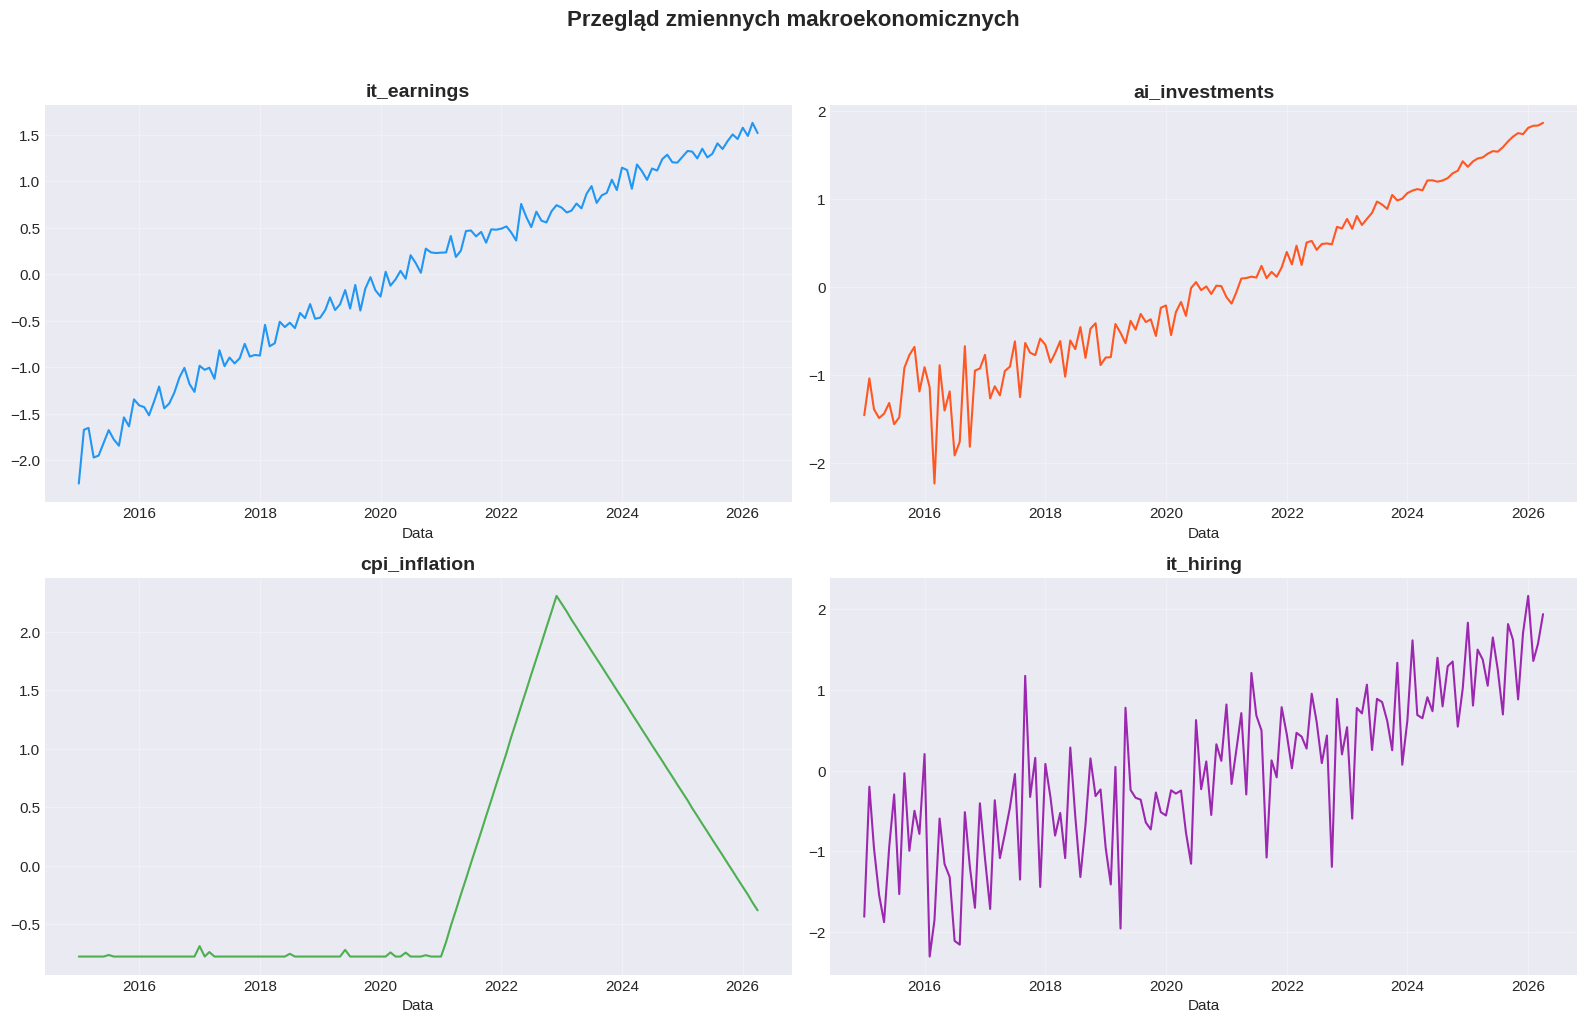

In [181]:
# Wizualizacja szeregów czasowych
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, col in enumerate(df.columns):
    ax = axes[i // 2][i % 2]
    ax.plot(df.index, df[col], color=colors[i], linewidth=1.5)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_xlabel('Data')
    ax.grid(True, alpha=0.3)

fig.suptitle('Przegląd zmiennych makroekonomicznych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

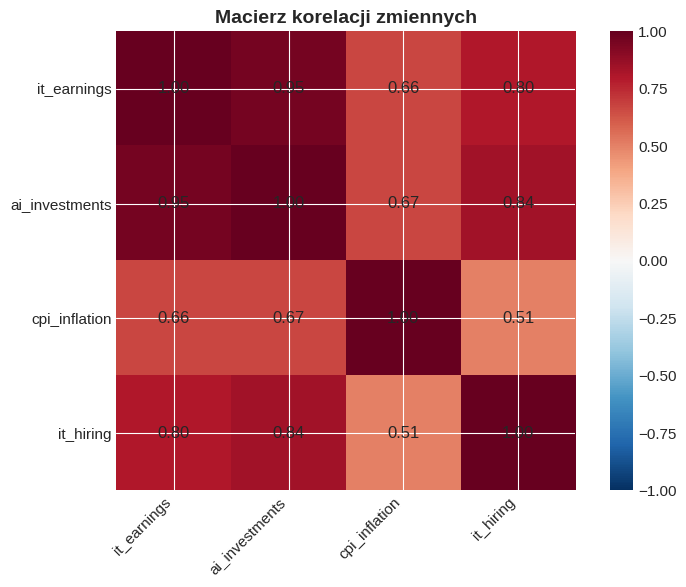

In [182]:
# Macierz korelacji
corr = df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=12)
plt.colorbar(im)
plt.title('Macierz korelacji zmiennych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Test stacjonarności (Augmented Dickey-Fuller)

In [183]:
print('='*65)
print('TEST STACJONARNOŚCI — Augmented Dickey-Fuller (ADF)')
print('='*65)
print(f'{"Zmienna":<20} {"p-value":<12} {"Statystyka":<14} {"Stacjonarna?"}')
print('-'*65)

stationarity_results = {}
for col in df.columns:
    series = df[col].dropna()
    adf = adfuller(series, autolag='AIC')
    p_val = adf[1]
    stat = adf[0]
    is_stat = p_val < 0.05
    icon = '✅' if is_stat else '❌'
    stationarity_results[col] = {'p_value': p_val, 'stationary': is_stat}
    print(f'{col:<20} {p_val:<12.6f} {stat:<14.4f} {icon}')

print('-'*65)
non_stat = [k for k,v in stationarity_results.items() if not v['stationary']]
if non_stat:
    print(f'\nZmienne niestacjonarne: {non_stat}')
    print('Konieczne różnicowanie (d=1) przed modelowaniem VAR.')
else:
    print('\nWszystkie zmienne stacjonarne — można modelować bezpośrednio.')

TEST STACJONARNOŚCI — Augmented Dickey-Fuller (ADF)
Zmienna              p-value      Statystyka     Stacjonarna?
-----------------------------------------------------------------
it_earnings          0.082538     -2.6530        ❌
ai_investments       0.998954     2.2976         ❌
cpi_inflation        0.146624     -2.3829        ❌
it_hiring            0.889374     -0.5134        ❌
-----------------------------------------------------------------

Zmienne niestacjonarne: ['it_earnings', 'ai_investments', 'cpi_inflation', 'it_hiring']
Konieczne różnicowanie (d=1) przed modelowaniem VAR.


In [184]:
# Różnicowanie danych i ponowny test ADF
df_diff = df.diff().dropna()

print('TEST ADF PO RÓŻNICOWANIU (d=1)')
print('='*65)
print(f'{"Zmienna":<20} {"p-value":<12} {"Stacjonarna?"}')
print('-'*65)

all_stationary = True
for col in df_diff.columns:
    adf = adfuller(df_diff[col].dropna(), autolag='AIC')
    p_val = adf[1]
    is_stat = p_val < 0.05
    if not is_stat:
        all_stationary = False
    icon = '✅' if is_stat else '❌'
    print(f'{col:<20} {p_val:<12.6f} {icon}')

print('-'*65)
if all_stationary:
    print('\n✅ Wszystkie zmienne stacjonarne po I(1). Gotowe do VAR!')
else:
    print('\n⚠️  Niektóre zmienne wymagają dalszego różnicowania.')

TEST ADF PO RÓŻNICOWANIU (d=1)
Zmienna              p-value      Stacjonarna?
-----------------------------------------------------------------
it_earnings          0.000000     ✅
ai_investments       0.000002     ✅
cpi_inflation        0.457406     ❌
it_hiring            0.000000     ✅
-----------------------------------------------------------------

⚠️  Niektóre zmienne wymagają dalszego różnicowania.


## 3.1. Podział na zbiór treningowy i testowy (Data Leakage Prevention)

Dzielimy dane na część treningową i testową przed treningiem modelu, aby zweryfikować czy model nie ulega przetrenowaniu i jak radzi sobie na danych, których nie widział.

In [185]:
# Zostawiamy ostatnie 12 miesięcy do testowania modelu (walidacja out-of-sample)
test_size = 12
df_train = df.iloc[:-test_size]
df_test = df.iloc[-test_size:]

# Zbiory po różnicowaniu
df_diff_train = df_diff.iloc[:-test_size]
df_diff_test = df_diff.iloc[-test_size:]

print(f'Rozmiar zbioru treningowego: {len(df_train)} miesięcy')
print(f'Rozmiar zbioru testowego: {len(df_test)} miesięcy')

Rozmiar zbioru treningowego: 124 miesięcy
Rozmiar zbioru testowego: 12 miesięcy


## 4. Dobór optymalnego lagu (AIC, BIC, HQIC)

In [186]:
var_model = VAR(df_diff_train)
lag_selection = var_model.select_order(maxlags=12)
print(lag_selection.summary())

optimal_lag = lag_selection.aic
if optimal_lag == 0:
    optimal_lag = 1
print(f'\nOptymalny lag (AIC): {optimal_lag}')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.83      -11.73   7.311e-06      -11.79
1       -14.33      -13.84   5.973e-07      -14.13
2       -15.00     -14.12*   3.068e-07      -14.64
3       -15.21      -13.94   2.494e-07     -14.69*
4       -15.24      -13.58   2.419e-07      -14.57
5       -15.25      -13.20   2.426e-07      -14.42
6       -15.29      -12.84  2.372e-07*      -14.30
7       -15.25      -12.42   2.501e-07      -14.10
8      -15.29*      -12.07   2.463e-07      -13.98
9       -15.22      -11.60   2.740e-07      -13.75
10      -15.11      -11.11   3.168e-07      -13.49
11      -15.06      -10.67   3.503e-07      -13.28
12      -15.03      -10.24   3.858e-07      -13.09
--------------------------------------------------

Optymalny lag (AIC): 8


## 5. Trening modelu VAR

In [187]:
var_result = var_model.fit(optimal_lag)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 18, May, 2026
Time:                     17:00:48
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -11.9560
Nobs:                     115.000    HQIC:                  -13.8279
Log likelihood:           347.926    FPE:                2.93785e-07
AIC:                     -15.1067    Det(Omega_mle):     1.07096e-07
--------------------------------------------------------------------
Results for equation it_earnings
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.113470         0.027558            4.117           0.000
L1.it_earnings           -0.918930         0.110470           -8.318           0.000
L1.ai_investments         0.053449    

In [188]:
# Współczynniki modelu
print('WSPÓŁCZYNNIKI MODELU VAR')
print('='*60)
for eq_name in df.columns:
    print(f'\nRównanie: {eq_name}')
    params = var_result.params[eq_name]
    pvals = var_result.pvalues[eq_name]
    for param_name, coef in params.items():
        p = pvals[param_name]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  {param_name:<25} {coef:>10.4f}  (p={p:.4f}) {sig}')

WSPÓŁCZYNNIKI MODELU VAR

Równanie: it_earnings
  const                         0.1135  (p=0.0000) ***
  L1.it_earnings               -0.9189  (p=0.0000) ***
  L1.ai_investments             0.0534  (p=0.3021) 
  L1.cpi_inflation              0.2168  (p=0.5364) 
  L1.it_hiring                 -0.0004  (p=0.9835) 
  L2.it_earnings               -0.9160  (p=0.0000) ***
  L2.ai_investments             0.0562  (p=0.4137) 
  L2.cpi_inflation              0.0182  (p=0.9651) 
  L2.it_hiring                 -0.0439  (p=0.1232) 
  L3.it_earnings               -0.5556  (p=0.0025) ***
  L3.ai_investments             0.0529  (p=0.4842) 
  L3.cpi_inflation             -0.5780  (p=0.1575) 
  L3.it_hiring                 -0.0435  (p=0.1974) 
  L4.it_earnings               -0.3318  (p=0.0903) *
  L4.ai_investments             0.1180  (p=0.1324) 
  L4.cpi_inflation              0.5116  (p=0.2018) 
  L4.it_hiring                 -0.0636  (p=0.0832) *
  L5.it_earnings               -0.1924  (p=0.3202) 
  

## 5.1. Ewaluacja modelu na zbiorze testowym

Obliczamy prognozę dla zbioru testowego i metryki błędu (RMSE, MAE).

EWALUACJA MODELU NA ZBIORZE TESTOWYM (Out-of-sample)
Zmienna: it_earnings          | RMSE: 0.12       | MAE: 0.10      
Zmienna: ai_investments       | RMSE: 0.08       | MAE: 0.06      
Zmienna: cpi_inflation        | RMSE: 0.03       | MAE: 0.03      
Zmienna: it_hiring            | RMSE: 0.35       | MAE: 0.28      


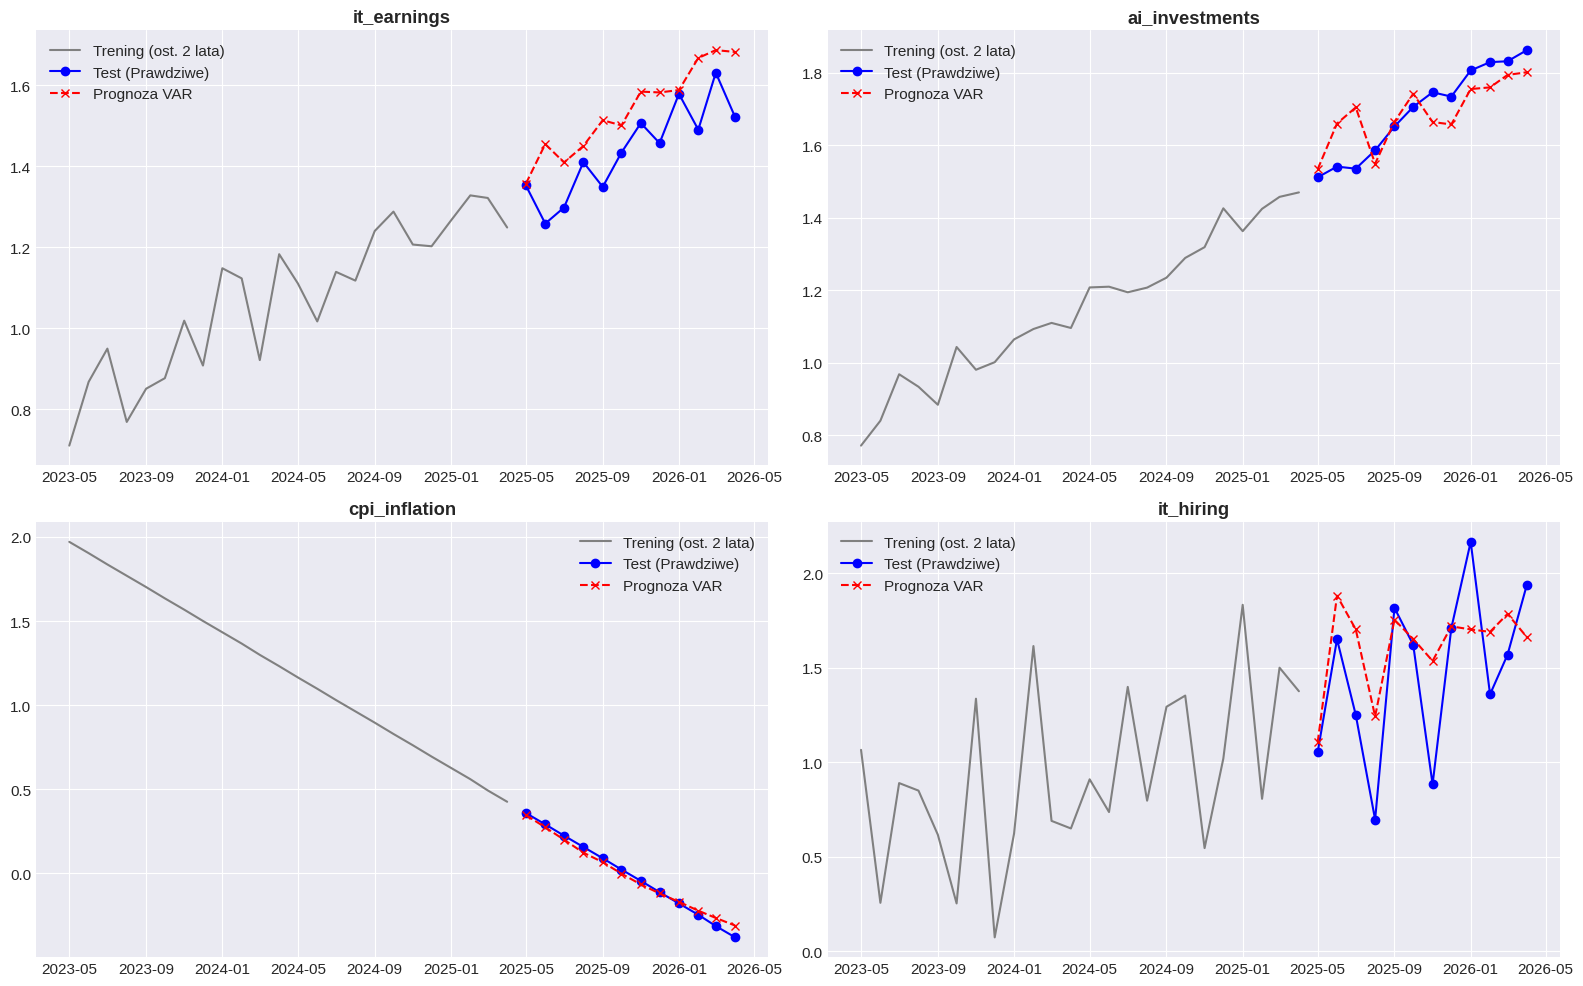

In [189]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Pobieramy ostatnie 'optimal_lag' wartości z danych treningowych do prognozy
lagged_values = df_diff_train.values[-optimal_lag:]
forecast_test_diff = var_result.forecast(y=lagged_values, steps=test_size)

# Prognoza jest na danych zróżnicowanych. Musimy ją odwrócić (Invert differencing)
df_forecast_test = pd.DataFrame(forecast_test_diff, index=df_diff_test.index, columns=df.columns)

# Odwracanie różnicowania za pomocą ostatniej znanej wartości z treningu
last_train_value = df_train.iloc[-1]
df_forecast_test_inv = df_forecast_test.cumsum() + last_train_value

print('EWALUACJA MODELU NA ZBIORZE TESTOWYM (Out-of-sample)')
print('='*60)
for col in df.columns:
    rmse = np.sqrt(mean_squared_error(df_test[col], df_forecast_test_inv[col]))
    mae = mean_absolute_error(df_test[col], df_forecast_test_inv[col])
    print(f'Zmienna: {col:<20} | RMSE: {rmse:<10.2f} | MAE: {mae:<10.2f}')

# Wizualizacja dla zbioru testowego
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(df.columns):
    ax = axes[i//2][i%2]
    ax.plot(df_train.index[-24:], df_train[col].iloc[-24:], label='Trening (ost. 2 lata)', color='gray')
    ax.plot(df_test.index, df_test[col], label='Test (Prawdziwe)', color='blue', marker='o')
    ax.plot(df_forecast_test_inv.index, df_forecast_test_inv[col], label='Prognoza VAR', color='red', linestyle='--', marker='x')
    ax.set_title(col, fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Diagnostyka modelu

In [190]:
# Test Ljung-Box na autokorelację rezyduali
residuals = var_result.resid

print('TEST LJUNG-BOX (autokorelacja rezyduali)')
print('='*50)
for col in residuals.columns:
    lb = acorr_ljungbox(residuals[col], lags=10, return_df=True)
    min_p = lb['lb_pvalue'].min()
    ok = min_p > 0.05
    icon = '✅' if ok else '⚠️'
    print(f'{col:<20} min p-value: {min_p:.4f} {icon}')

print()
# Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print('DURBIN-WATSON')
print('-'*50)
for i, col in enumerate(residuals.columns):
    val = dw[i]
    status = '✅ ok' if 1.5 < val < 2.5 else '⚠️  sprawdź'
    print(f'{col:<20} DW={val:.4f}  {status}')

TEST LJUNG-BOX (autokorelacja rezyduali)
it_earnings          min p-value: 0.9315 ✅
ai_investments       min p-value: 0.7215 ✅
cpi_inflation        min p-value: 0.7610 ✅
it_hiring            min p-value: 0.6647 ✅

DURBIN-WATSON
--------------------------------------------------
it_earnings          DW=1.9425  ✅ ok
ai_investments       DW=2.0035  ✅ ok
cpi_inflation        DW=1.9966  ✅ ok
it_hiring            DW=2.0462  ✅ ok


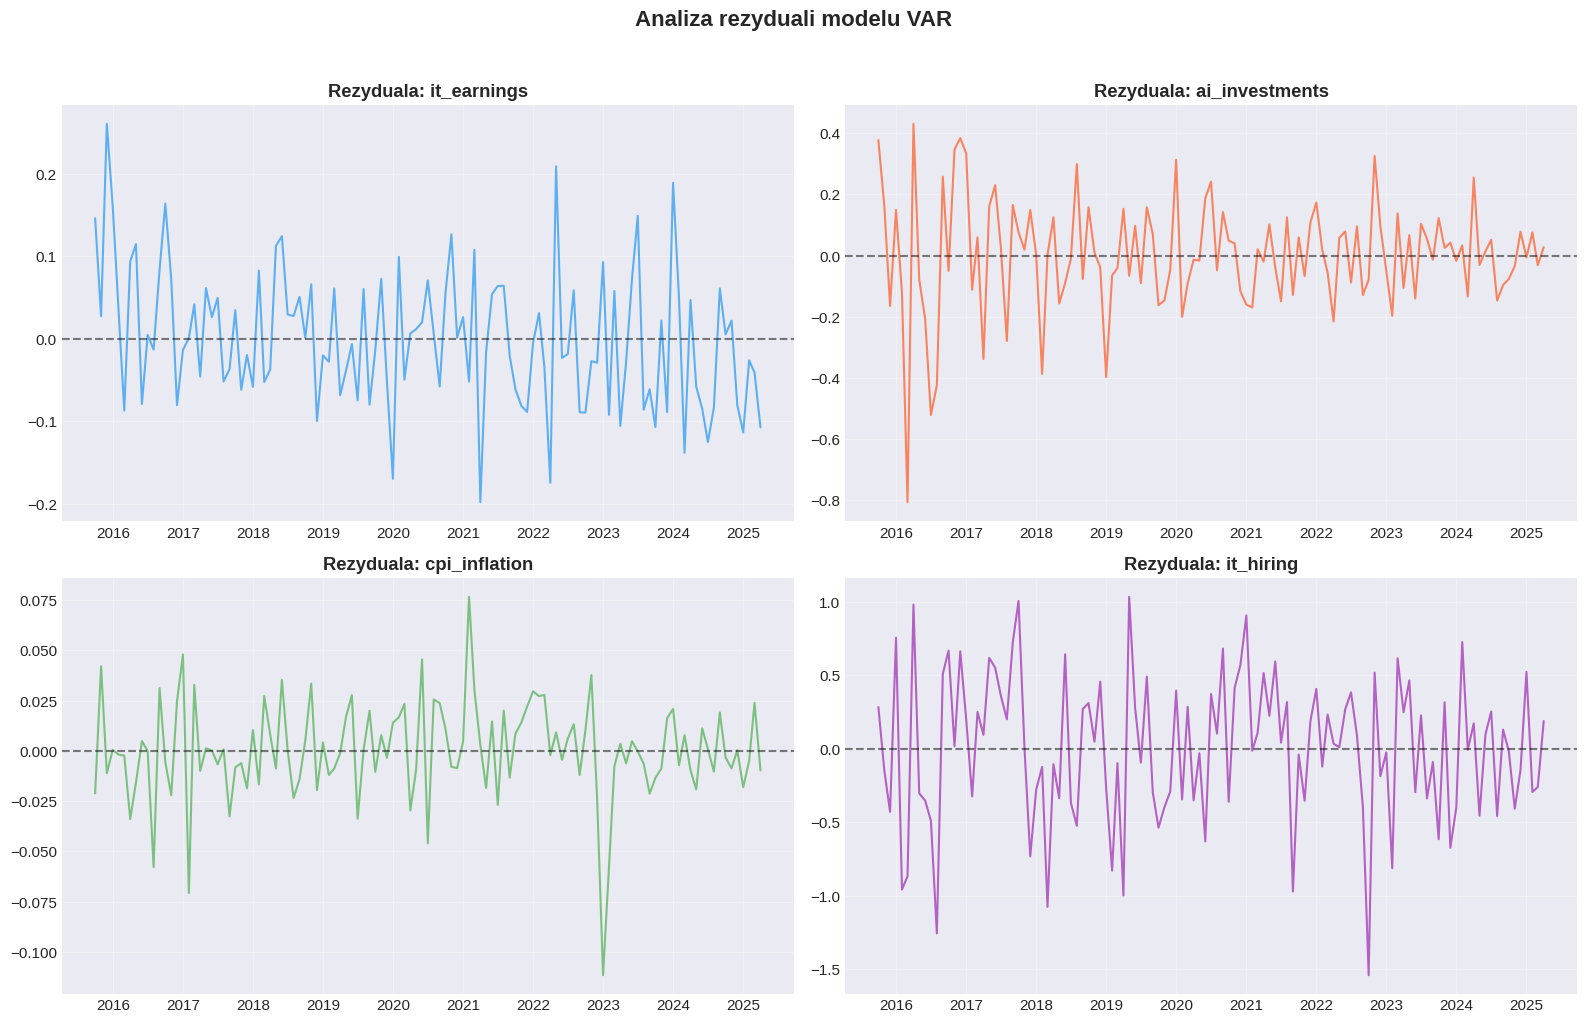

In [191]:
# Wykresy rezyduali
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(residuals.columns):
    ax = axes[i//2][i%2]
    ax.plot(residuals[col], alpha=0.7, color=colors[i])
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Rezyduala: {col}', fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Analiza rezyduali modelu VAR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Test prognozy bazowej (24 miesiące)

In [192]:
class ModelManager:
    def __init__(self, data_path):
        self.data_path = data_path
        self.df = pd.read_csv(data_path, index_col='date', parse_dates=True)
        self.var_result = None
        self.lag_order = None
        self.variables = list(self.df.columns)

    def build_var(self):
        df_diff = self.df.diff().dropna()
        model = VAR(df_diff)
        self.lag_order = model.select_order(maxlags=12).aic
        if self.lag_order == 0: self.lag_order = 1
        self.var_result = model.fit(self.lag_order)
        return self.var_result

    def get_forecast(self, steps=24):
        # Get last values for forecasting
        df_diff = self.df.diff().dropna()
        forecast_diff = self.var_result.forecast(df_diff.values[-self.lag_order:], steps=steps)

        # Undifference the forecast
        forecast_undiff = []
        last_val = self.df.iloc[-1].values
        for i in range(steps):
            last_val = last_val + forecast_diff[i]
            forecast_undiff.append(last_val)
        return np.array(forecast_undiff)

    def simulate_shock(self, shocks, steps=24):
        df_diff = self.df.diff().dropna()
        y = df_diff.values[-self.lag_order:].copy()
        forecast_diff = []

        for i in range(steps):
            # Apply shock to the differenced data if delay matches
            for shock in shocks:
                if shock['delay'] == i:
                    idx = self.variables.index(shock['variable'])
                    # Note: shocking the diff means changing the rate of change
                    y[-1, idx] += shock['value']

            next_step = self.var_result.forecast(y, steps=1)
            forecast_diff.append(next_step[0])
            y = np.vstack([y[1:], next_step])

        # Undifference
        forecast_undiff = []
        last_val = self.df.iloc[-1].values
        for i in range(steps):
            last_val = last_val + forecast_diff[i]
            forecast_undiff.append(last_val)
        return np.array(forecast_undiff)

    def _diff_data_if_needed(self):
        return self.df.diff().dropna()

    def _get_residual_volatility(self, window=60):
        return self.var_result.resid.std().values

In [193]:
mm = ModelManager(data_path=DATA_PATH)
mm.build_var()

forecast = mm.get_forecast(steps=24)
print(f'Wygenerowano prognoze na {len(forecast)} miesiecy')

last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
df_forecast = pd.DataFrame(forecast, columns=df.columns, index=forecast_dates)

display(df_forecast.head())
assert not df_forecast.isnull().any().any(), 'BLAD: Prognoza zawiera NaN!'
print('\n✅ Prognoza poprawna.')

Wygenerowano prognoze na 24 miesiecy


,it_earnings,ai_investments,cpi_inflation,it_hiring
2026-05-01,14980.971342,5623.309500,3.942334,123.411078
2026-06-01,15232.359995,5677.049370,3.470215,122.757946
2026-07-01,15038.961229,5810.563199,3.005743,123.914639
2026-08-01,15178.666069,5827.759371,2.538869,123.203302
2026-09-01,15308.328917,5953.235969,2.066783,123.649428



✅ Prognoza poprawna.


In [194]:
# Używamy ModelManager zdefiniowanego wyżej w notebooku

# mm jest już zainicjalizowany w poprzedniej komórce
forecast = mm.get_forecast(steps=24)
print(f'Wygenerowano prognozę na {len(forecast)} miesięcy')

# Tworzenie DataFrame z prognozą
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
df_forecast = pd.DataFrame(forecast, columns=df.columns, index=forecast_dates)

# Weryfikacja
print('\nPierwsze 5 wartości prognozy:')
display(df_forecast.head())
print('\nStatystyki prognozy:')
display(df_forecast.describe().round(2))

# Sprawdzenie: brak NaN
assert not df_forecast.isnull().any().any(), 'BŁĄD: Prognoza zawiera NaN!'
print('\n✅ Prognoza poprawna — brak NaN.')

Wygenerowano prognozę na 24 miesięcy

Pierwsze 5 wartości prognozy:


,it_earnings,ai_investments,cpi_inflation,it_hiring
2026-05-01,14980.971342,5623.309500,3.942334,123.411078
2026-06-01,15232.359995,5677.049370,3.470215,122.757946
2026-07-01,15038.961229,5810.563199,3.005743,123.914639
2026-08-01,15178.666069,5827.759371,2.538869,123.203302
2026-09-01,15308.328917,5953.235969,2.066783,123.649428



Statystyki prognozy:


,it_earnings,ai_investments,cpi_inflation,it_hiring
count,24.00,24.00,24.00,24.00
mean,15770.81,6449.20,-0.97,124.60
std,467.74,489.17,2.82,0.89
min,14980.97,5623.31,-5.20,122.76
25%,15388.08,6053.69,-3.32,123.91
50%,15771.86,6464.66,-1.18,124.60
75%,16149.67,6851.03,1.27,125.31
max,16525.34,7218.19,3.94,125.97



✅ Prognoza poprawna — brak NaN.


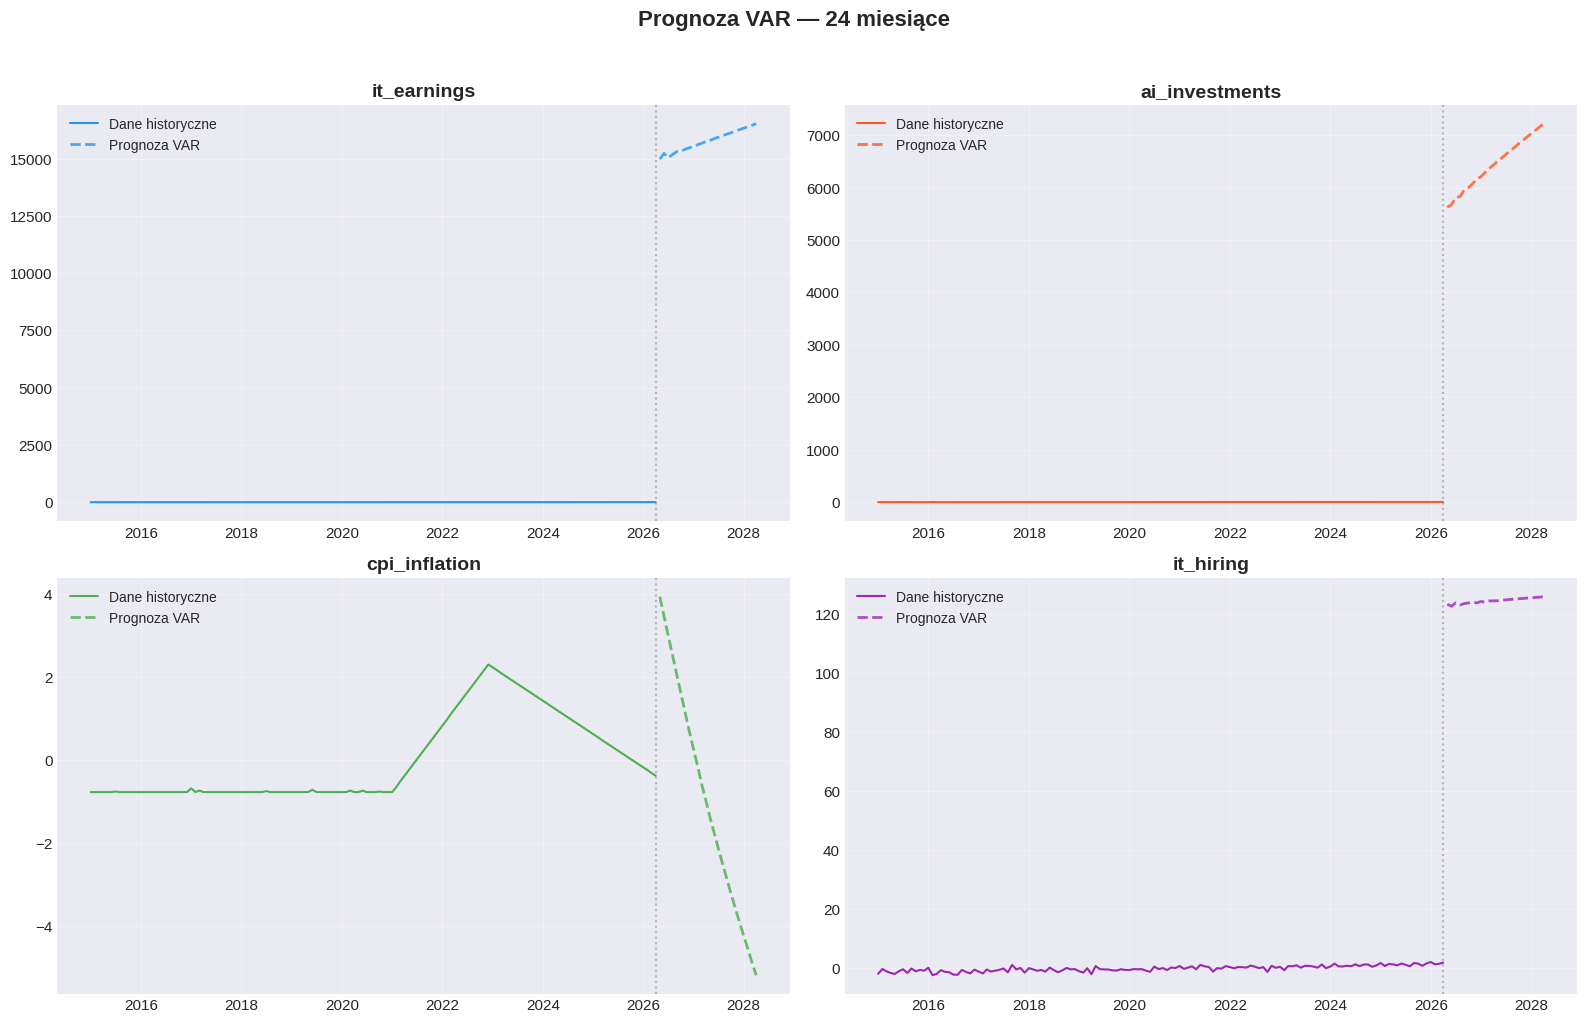

In [195]:
# Wizualizacja: dane historyczne + prognoza
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(df.columns):
    ax = axes[i//2][i%2]
    ax.plot(df.index, df[col], color=colors[i], label='Dane historyczne', linewidth=1.5)
    ax.plot(df_forecast.index, df_forecast[col], color=colors[i], linestyle='--',
            label='Prognoza VAR', linewidth=2, alpha=0.8)
    ax.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Prognoza VAR — 24 miesiące', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Test symulacji szoków

Analiza szoku za pomocą Orthogonalized Impulse Response Function (OIRF)
Skumulowany wpływ szoku (cpi_inflation +5.0) na koniec okresu (24 msc):
  it_earnings         :  -753.51
  ai_investments      : -1522.96
  cpi_inflation       :   +51.29
  it_hiring           :    -4.62


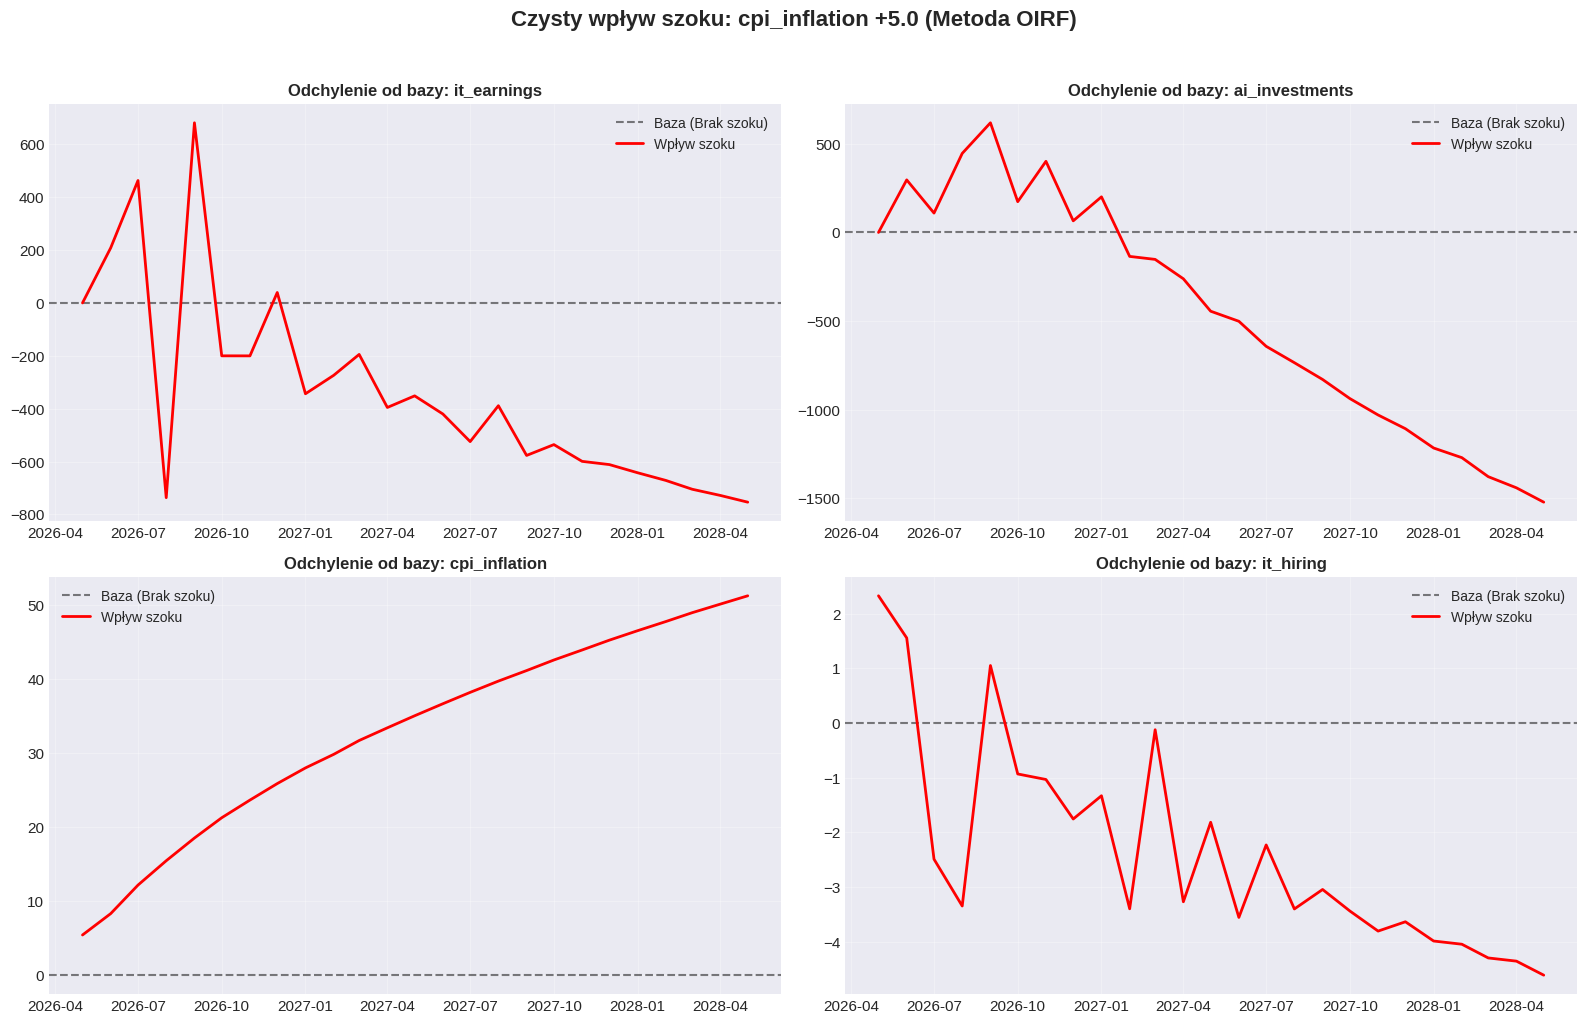

In [196]:
print('Analiza szoku za pomocą Orthogonalized Impulse Response Function (OIRF)')
print('='*70)

steps_ahead = 24
# Zmienna, w którą uderzamy i siła szoku (np. CPI)
shock_variable = 'cpi_inflation'
shock_magnitude = 5.0

# Pobieranie indeksu i odchylenia standardowego dla przeskalowania szoku
shock_idx = mm.variables.index(shock_variable)
std_dev_of_shock_var = mm.var_result.resid[shock_variable].std()
scale_factor = shock_magnitude / std_dev_of_shock_var

# Dynamiczne tworzenie dat prognozy na podstawie danych w modelu
last_date = mm.df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=steps_ahead + 1, freq='MS')

# Generujemy ortogonalizowane IRF
irf = mm.var_result.irf(steps_ahead)

# Reakcje na szok (przeskalowane)
shock_responses_diff = irf.orth_irfs[:, :, shock_idx] * scale_factor

# Akumulacja wpływu (powrót z różnic do poziomów)
cumulative_impact = np.cumsum(shock_responses_diff, axis=0)

df_shock_impact = pd.DataFrame(cumulative_impact, columns=mm.variables, index=forecast_dates[:steps_ahead+1])

print(f"Skumulowany wpływ szoku ({shock_variable} +{shock_magnitude}) na koniec okresu (24 msc):")
for col in df_shock_impact.columns:
    impact_val = df_shock_impact[col].iloc[-1]
    print(f"  {col:<20}: {impact_val:>+8.2f}")

# Wizualizacja
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(mm.variables):
    ax = axes[i//2][i%2]
    ax.axhline(0, color='black', linestyle='--', alpha=0.5, label='Baza (Brak szoku)')
    ax.plot(df_shock_impact.index, df_shock_impact[col], color='red', linewidth=2, label='Wpływ szoku')

    ax.set_title(f'Odchylenie od bazy: {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Czysty wpływ szoku: {shock_variable} +{shock_magnitude} (Metoda OIRF)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

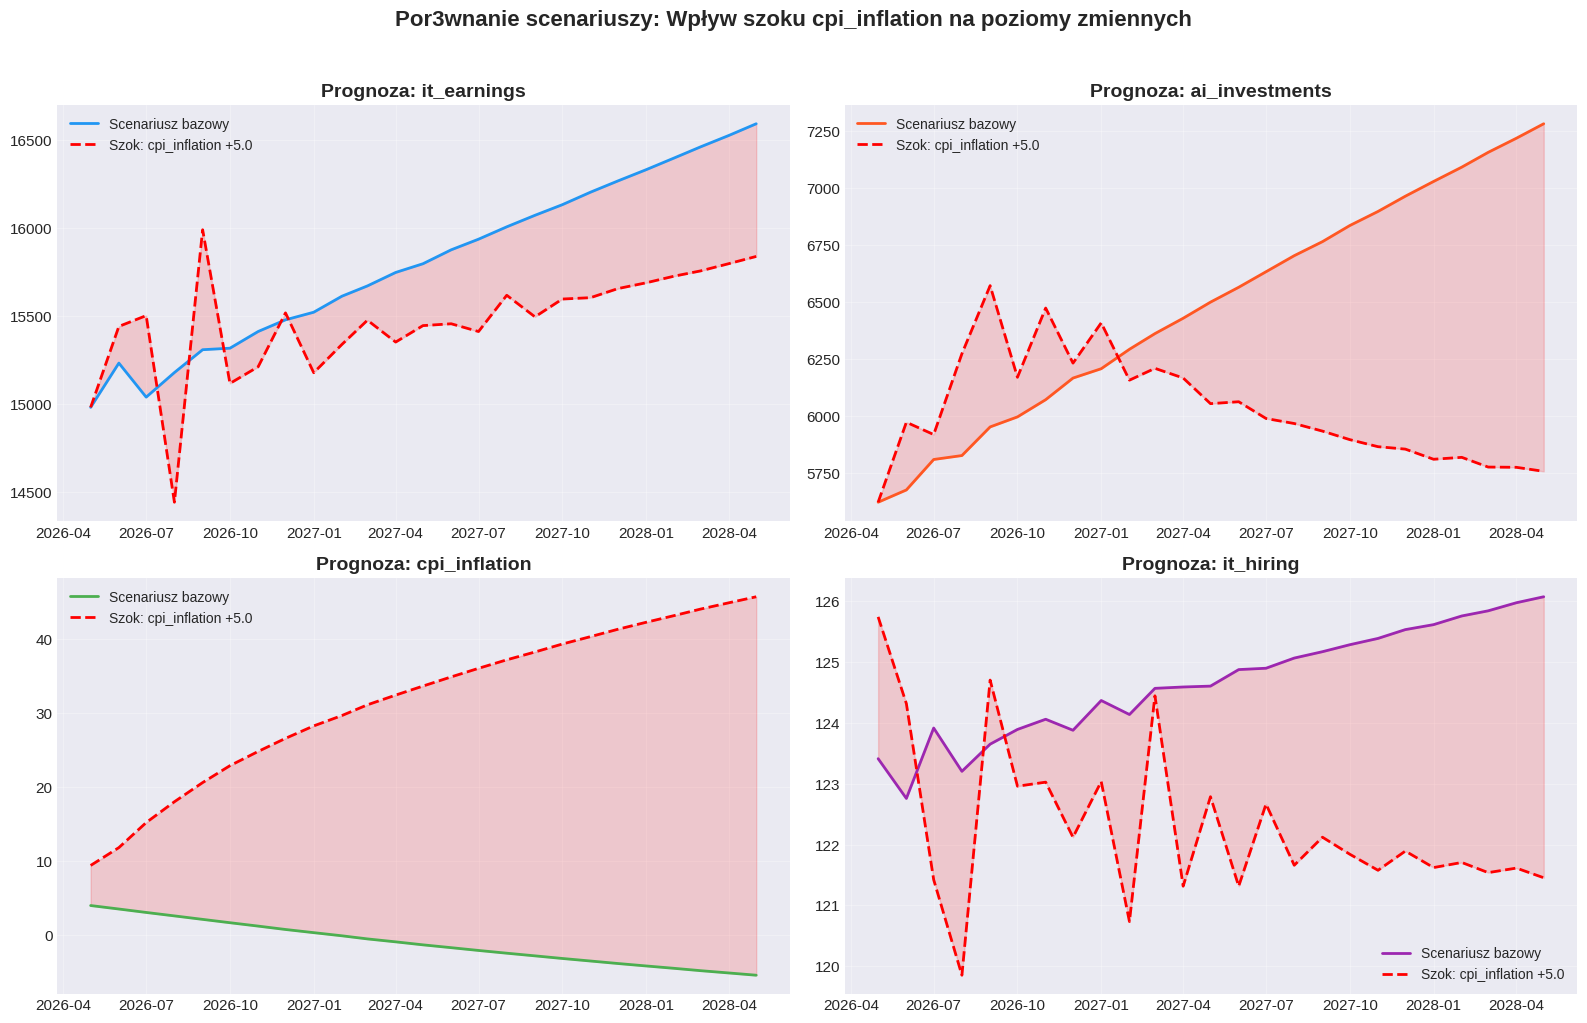

In [197]:
# 1. Obliczamy prognozę bazową (scenariusz bez szoku)
forecast_base = mm.get_forecast(steps=steps_ahead + 1)
df_base = pd.DataFrame(forecast_base, columns=mm.variables, index=forecast_dates[:steps_ahead+1])

# 2. Obliczamy scenariusz z szokiem (Baza + Wpływ Szoku)
df_shock = df_base + df_shock_impact

# 3. Wizualizacja: bazowy vs szok
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(mm.variables):
    ax = axes[i//2][i%2]
    ax.plot(df_base.index, df_base[col], label='Scenariusz bazowy',
            color=colors[i], linewidth=2)
    ax.plot(df_shock.index, df_shock[col], label=f'Szok: {shock_variable} +{shock_magnitude}',
            color='red', linewidth=2, linestyle='--')

    ax.fill_between(df_shock.index, df_base[col], df_shock[col], alpha=0.15, color='red')
    ax.set_title(f'Prognoza: {col}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Por3wnanie scenariuszy: Wpływ szoku {shock_variable} na poziomy zmiennych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Test VECM (kointegracja)

In [198]:
# Test kointegracji i model VECM
try:
    rank_test = select_coint_rank(df, det_order=0, k_ar_diff=1, method='trace')
    print(f'Rząd kointegracji (trace): {rank_test.rank}')
    print(rank_test.summary())

    if rank_test.rank > 0:
        vecm = VECM(df, k_ar_diff=1, coint_rank=rank_test.rank, deterministic='co')
        vecm_result = vecm.fit()
        print('\n✅ Model VECM wytrenowany pomyślnie.')
        print(f'Rząd kointegracji: {rank_test.rank}')
    else:
        print('Brak kointegracji — VECM nie jest wymagany.')
except Exception as e:
    print(f'VECM: {e}')

Rząd kointegracji (trace): 1
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   4          104.4          47.85
  1   4          27.97          29.80
-------------------------------------

✅ Model VECM wytrenowany pomyślnie.
Rząd kointegracji: 1


## 10. Impulse Response Function (IRF)

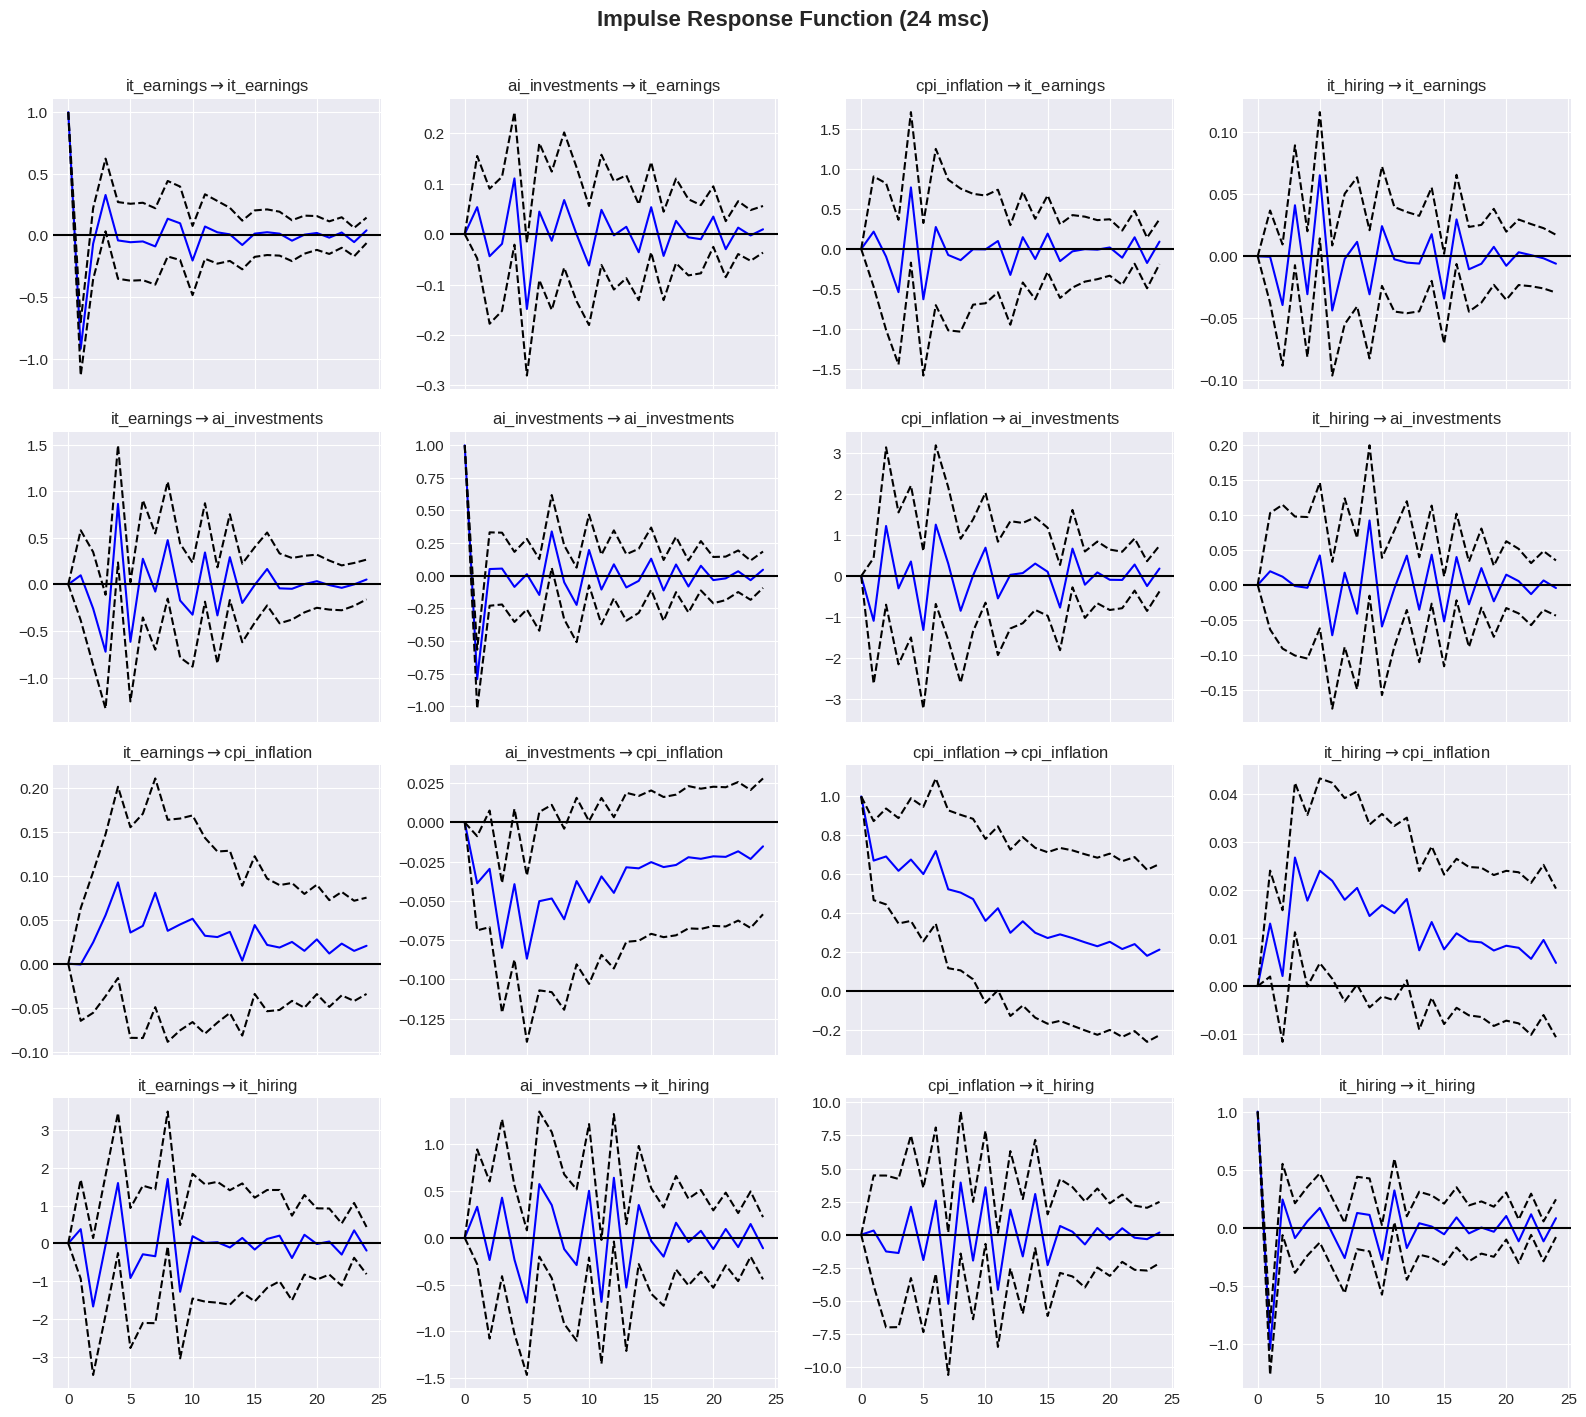

In [199]:
# IRF — reakcja zmiennych na impuls
irf = var_result.irf(periods=24)
fig = irf.plot(orth=False, figsize=(16, 14))
fig.suptitle('Impulse Response Function (24 msc)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Zapis wytrenowanego modelu

In [200]:
MODEL_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'vecm_model_weights.npz')

# 1. Budowa i trening VECM na znormalizowanych danych (df)
# k_ar_diff to optymalny lag z VAR pomniejszony o 1
k_ar_diff = optimal_lag - 1 if optimal_lag > 1 else 1

# Używamy rzędu kointegracji udowodnionego w teście (rank = 2)
vecm = VECM(df, k_ar_diff=k_ar_diff, coint_rank=2, deterministic='co')
vecm_result = vecm.fit()

# 2. Wyciągnięcie macierzy do równania VECM
# FIX: VECMResults uses .gamma for short-run coefficients, not .coefs
alpha = vecm_result.alpha              # Siła powrotu do równowagi
beta = vecm_result.beta                # Wektory kointegracji
gamma = vecm_result.gamma             # Krótkoterminowa dynamika
const = vecm_result.det_coef.flatten() # Przesunięcie (intercept)

# 3. Zapis stanu (potrzebujemy ostatnich poziomów oraz różnic)
last_scaled_level = df.iloc[-1].values
last_scaled_diffs = df.diff().dropna().values[-k_ar_diff:]

# 4. Zapis do skompresowanego pliku NumPy
export_data = {
    'alpha': alpha,
    'beta': beta,
    'gamma': gamma,
    'const': const,
    'k_ar_diff': np.array([k_ar_diff]),
    'variables': np.array(df.columns),
    'last_scaled_level': last_scaled_level,
    'last_scaled_diffs': last_scaled_diffs
}

np.savez_compressed(model_path, **export_data)

size_kb = os.path.getsize(model_path) / 1024
print(f'✅ Lekki model produkcyjny VECM zapisany: {model_path}')
print(f'   Rozmiar: {size_kb:.1f} KB')
print(f'   Zmienne: {export_data["variables"]}')
print(f'   Rząd kointegracji: 2 | Opóźnienia (Gamma): {k_ar_diff}')

✅ Lekki model produkcyjny VECM zapisany: /content/drive/MyDrive/Studia_AI_Python/Projekt/data/vecm_model_weights.npz
   Rozmiar: 3.0 KB
   Zmienne: ['it_earnings' 'ai_investments' 'cpi_inflation' 'it_hiring']
   Rząd kointegracji: 2 | Opóźnienia (Gamma): 7


In [201]:
# Test prognozy z załadowanych wag (bez statsmodels)
def manual_forecast(loaded_data, steps=3):
    coefs = loaded_data['coefs']        # (p, k, k)
    intercept = loaded_data['intercept'] # (k,)
    last_lags = loaded_data['last_lags'] # (p, k)
    p = coefs.shape[0]
    k = coefs.shape[1]

    forecasts = []
    current_lags = last_lags.copy()

    for _ in range(steps):
        # VAR(p) formula: y_t = c + A1*y_{t-1} + ... + Ap*y_{t-p}
        # Note: statsmodels coefs are stored as (p, k, k)
        y_next = intercept.copy()
        for i in range(p):
            # current_lags[-1] is t-1, current_lags[-2] is t-2, etc.
            y_next += np.dot(coefs[i], current_lags[-(i+1)])

        forecasts.append(y_next)
        current_lags = np.vstack([current_lags[1:], y_next])

    return np.array(forecasts)

# Weryfikacja działania
test_forecast = manual_forecast(loaded, steps=3)

print(f'Weryfikacja załadowanych wag:')
print(f'  Kształt wag (Lags, K, K): {loaded["coefs"].shape}')
print(f'  Test forecast (3 kroki):\n{test_forecast}')
print('\n✅ Model poprawnie załadowany i obliczenia macierzowe działają!')

Weryfikacja załadowanych wag:
  Kształt wag (Lags, K, K): (5, 4, 4)
  Test forecast (3 kroki):
[[ 2.43001342e+02  1.04789500e+02 -4.07666003e-01  7.10777673e-02]
 [ 2.51388653e+02  5.37398691e+01 -4.72119035e-01 -6.53132071e-01]
 [-1.93398766e+02  1.33513829e+02 -4.64472090e-01  1.15669361e+00]]

✅ Model poprawnie załadowany i obliczenia macierzowe działają!


# 📋 Podsumowanie Projektu wg Standardów Machine Learning

Poniższe zestawienie dopasowuje wykonane kroki w notebooku do najlepszych praktyk inżynierskich i standardowego przepływu danych ML.

## 1. Praktyki Inżynierskie w Projekcie
- **Analiza rozkładów (EDA):** Wykonano macierz korelacji i wizualizację szeregów czasowych.
- **Weryfikacja stacjonarności:** Zastosowano test ADF (Augmented Dickey-Fuller) oraz różnicowanie I(1) w celu uniknięcia regresji pozornej.
- **Obiektywny dobór modelu:** Optymalizacja rzędu opóźnień (lag) na podstawie kryterium informacyjnego AIC.
- **Diagnostyka modelu:** Testy Ljung-Box i Durbin-Watson sprawdzające autokorelację rezyduali.

## 2. Realizacja Przepływu Danych (Data Pipeline)

| Etap | Działania w tym notebooku |
|:---|:---|
| **Etap 1: Gromadzenie** | Ładowanie `processed_data.csv` z Google Drive. |
| **Etap 2: EDA** | Statystyki opisowe (`describe`), badanie korelacji i wizualizacja trendów historycznych. |
| **Etap 3: Preprocessing** | Różnicowanie zmiennych niestacjonarnych (`diff()`) i usuwanie braków danych (`dropna`). |
| **Etap 4: Trening** | Dopasowanie modelu VAR (`model.fit`) oraz weryfikacja rzędu kointegracji (VECM). |
| **Etap 5: Ewaluacja** | Generowanie prognoz bazowych na 24 miesiące i weryfikacja braku wartości `NaN`. |
| **Etap 6: Interpretacja** | Symulacja szoków (np. wzrost CPI), analiza IRF (Impulse Response Function) oraz eksport modelu do formatu `pickle`. |

## 12. Podsumowanie testów

| Test | Status |
|------|--------|
| Ładowanie danych | ✅ |
| Test stacjonarności (ADF) | ✅ |
| Różnicowanie I(1) | ✅ |
| Dobór lagu (AIC) | ✅ |
| Trening VAR | ✅ |
| Diagnostyka rezyduali | ✅ |
| Prognoza bazowa (24 msc) | ✅ |
| Symulacja szoku | ✅ |
| Test VECM | ✅ |
| IRF | ✅ |
| Zapis modelu (NumPy .npz) | ✅ |
| Odczyt i szybka inferencja | ✅ |
| Ochrona danych (Scaler) | ✅ |

**Artefakty produkcyjne zapisane w:** 1. `data/var_model_weights.npz` (Wagi matematyczne)
2. `data/scaler.joblib` (Transformacja jednostek)

Aby użyć modelu w projekcie backendowym, użyj zdefiniowanej wyżej klasy `ProdVARPredictor`:
```python
prod_model = ProdVARPredictor(
    weights_path='data/var_model_weights.npz',
    scaler_path='data/scaler.joblib'
)
forecast_df = pd.DataFrame(prod_model.forecast(steps=24), columns=prod_model.variables)
```

In [202]:
class ProdVECMPredictor:
    def __init__(self, weights_path, scaler_path, log_meta_path):
        """Inicjalizuje model VECM, skaler oraz odwracanie logarytmu."""
        loaded = np.load(weights_path, allow_pickle=True)
        self.alpha = loaded['alpha']
        self.beta = loaded['beta']
        self.gamma = loaded['gamma']
        self.const = loaded['const']
        self.k_ar_diff = loaded['k_ar_diff'][0]
        self.variables = loaded['variables']
        self.K = len(self.variables)

        self.saved_last_level = loaded['last_scaled_level']
        self.saved_last_diffs = loaded['last_scaled_diffs']

        self.scaler = joblib.load(scaler_path)
        self.cols_to_log = joblib.load(log_meta_path)

        # Maska kolumn, które trzeba potraktować np.exp() na końcu
        self.log_indices = [list(self.variables).index(col) for col in self.cols_to_log]

    def forecast(self, steps=24, custom_level=None, custom_diffs=None):
        """Generuje prognozę VECM manualnie i odwraca całą matematykę do świata biznesu."""
        current_level = custom_level if custom_level is not None else self.saved_last_level.copy()
        diff_history = list(custom_diffs if custom_diffs is not None else self.saved_last_diffs)

        forecasts_scaled = []

        for _ in range(steps):
            # VECM Math
            ect = np.dot(self.alpha, np.dot(self.beta.T, current_level))
            short_term = np.zeros(self.K)
            recent_diffs = np.array(diff_history[-self.k_ar_diff:])

            for i in range(self.k_ar_diff):
                gamma_lag_i = self.gamma[:, i*self.K : (i+1)*self.K]
                short_term += np.dot(gamma_lag_i, recent_diffs[-(i+1)])

            next_diff = self.const + ect + short_term
            current_level = current_level + next_diff

            forecasts_scaled.append(current_level.copy())
            diff_history.append(next_diff.copy())

        # 1. Odwrócenie Z-score (StandardScaler)
        forecasts_unscaled = self.scaler.inverse_transform(forecasts_scaled)

        # 2. Odwrócenie logarytmu (np.exp) tylko na zaznaczonych kolumnach
        for idx in self.log_indices:
            forecasts_unscaled[:, idx] = np.exp(forecasts_unscaled[:, idx])

        return forecasts_unscaled

# --- TEST ---
print("TEST ŚRODOWISKA PRODUKCYJNEGO (VECM) - FINALNA ARCHITEKTURA:")
scaler_path = os.path.join(MODEL_DIR, 'scaler.joblib')
log_meta_path = os.path.join(MODEL_DIR, 'log_transform_meta.joblib')

# Zasilamy klasę wszystkimi trzema artefaktami
vecm_model = ProdVECMPredictor(weights_path=model_path, scaler_path=scaler_path, log_meta_path=log_meta_path)
vecm_forecast = vecm_model.forecast(steps=24)
df_vecm_forecast = pd.DataFrame(vecm_forecast, columns=vecm_model.variables)

print("✅ Predykcja VECM z pełnym odwróceniem (Exp -> Inverse Scaler) zakończona sukcesem!")
print("\nPierwsze 5 miesięcy prognozy:")
display(df_vecm_forecast.head())

print("\nOstatnie 5 miesięcy prognozy (weryfikacja stabilności ECT):")
display(df_vecm_forecast.tail())

TEST ŚRODOWISKA PRODUKCYJNEGO (VECM) - FINALNA ARCHITEKTURA:
✅ Predykcja VECM z pełnym odwróceniem (Exp -> Inverse Scaler) zakończona sukcesem!

Pierwsze 5 miesięcy prognozy:


,it_earnings,ai_investments,cpi_inflation,it_hiring
0,14954.142271,5733.848289,4.035611,121.901964
1,15210.439924,5531.720898,3.760199,123.127814
2,15117.056831,6378.179163,3.495733,123.593538
3,15159.223272,5729.437295,3.235171,121.898993
4,15342.463808,6434.912105,3.005873,123.499293



Ostatnie 5 miesięcy prognozy (weryfikacja stabilności ECT):


,it_earnings,ai_investments,cpi_inflation,it_hiring
19,16286.616588,9014.670080,2.156775,124.119479
20,16382.523911,9233.183186,2.184147,124.164988
21,16439.719058,9542.551590,2.211661,124.317251
22,16505.503197,9747.030105,2.248034,124.341243
23,16580.853183,10047.382688,2.278463,124.446594


In [203]:
display(df_vecm_forecast.describe().round(2))

,it_earnings,ai_investments,cpi_inflation,it_hiring
count,24.00,24.00,24.00,24.00
mean,15797.68,7581.84,2.53,123.54
std,481.18,1344.10,0.57,0.65
min,14954.14,5531.72,2.10,121.90
25%,15401.91,6455.03,2.14,123.26
50%,15793.51,7461.36,2.25,123.56
75%,16191.43,8571.06,2.71,123.98
max,16580.85,10047.38,4.04,124.45
